In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/4th yr/ImageDataset"

In [ ]:
import tensorflow as tf

img_height = 180
img_width = 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 7288 files belonging to 20 classes.
Using 5831 files for training.
Found 7288 files belonging to 20 classes.
Using 1457 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['ARATILES', 'AVOCADO', 'Baobab (Adansonia digitata)', 'Breadfruit Tree (Artocarpus altilis)', 'COCOA', 'Cedar of Lebanon (Cedrus libani)', 'DUHAT', 'Dragon Blood Tree', 'Eucalyptus', 'GUAVA', 'KAMIAS', 'Kapur Tree (Dryobalanops aromatica)', 'LANGKA', 'LANZONES', 'MANGOSTEEN', 'Monkey Pod Tree (Samanea saman)', 'PAPAYA', 'RAMBUTAN', 'Soursop Tree (Annona muricata)', 'Wollemi Pine (Wollemia nobilis)']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
layers.Conv2D(16, 3, padding='same', activation='relu'),
layers.MaxPooling2D(),
layers.Conv2D(32, 3, padding='same', activation='relu'),
layers.MaxPooling2D(),
layers.Conv2D(64, 3, padding='same', activation='relu'),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(len(class_names))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy']
)

In [ ]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/4th yr/ImageDataset"

bad_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            bad_images.append(path)

print("Corrupted images:", bad_images)

Corrupted images: ['/content/drive/MyDrive/4th yr/ImageDataset/image_classifier.keras']


In [ ]:
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
    120/Unknown 215s 1s/step - accuracy: 0.1100 - loss: 2.9111

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


120/120 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.1109 - loss: 2.9085 - val_accuracy: 0.5571 - val_loss: 1.6855
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7071 - loss: 1.0705 - val_accuracy: 0.9199 - val_loss: 0.3304
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9657 - loss: 0.1517 - val_accuracy: 0.9800 - val_loss: 0.1179
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9888 - loss: 0.0681 - val_accuracy: 0.9776 - val_loss: 0.1421
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9915 - loss: 0.0684 - val_accuracy: 0.9835 - val_loss: 0.1218
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9994 - loss: 0.0112 - val_accuracy: 0.9847 - val_loss: 0.0888
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9981 - loss: 0.0168 - val_accuracy: 0.9847 - val_loss: 0.0836
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9983 - loss: 0.0065 - val_accuracy: 0.984

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/4th yr/ImageDataset"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
            os.remove(os.path.join(root, file))

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.9878 - loss: 0.0676
Validation Accuracy: 0.9858657121658325


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/csc-lw3a_screenshots", exist_ok=True)
print("Screenshot folder ready.")

Screenshot folder ready.


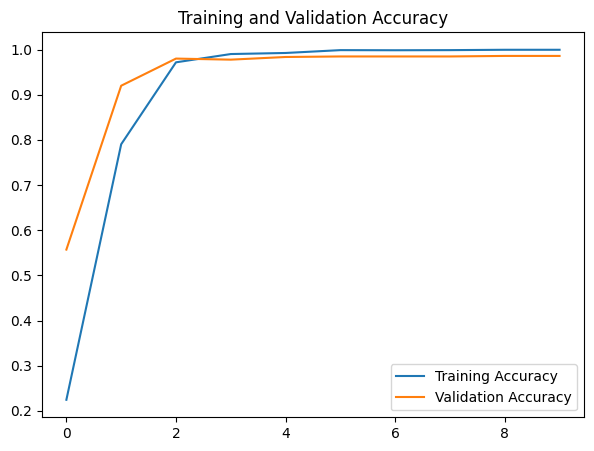

Saved: accuracy-plot.png


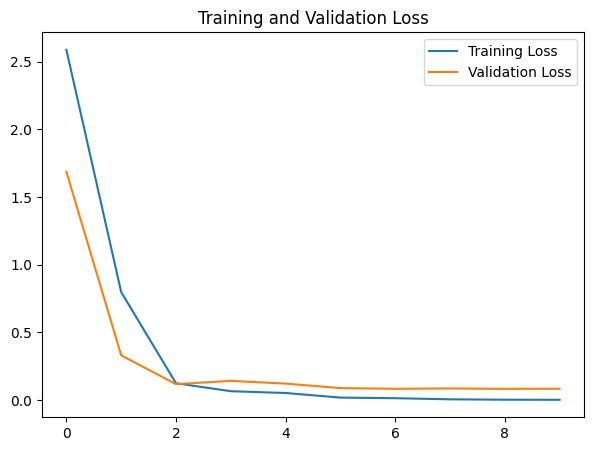

Saved: loss-plot.png


In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Plot
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/accuracy-plot.png", bbox_inches='tight')
plt.show()
print("Saved: accuracy-plot.png")

# Loss Plot
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/loss-plot.png", bbox_inches='tight')
plt.show()
print("Saved: loss-plot.png")

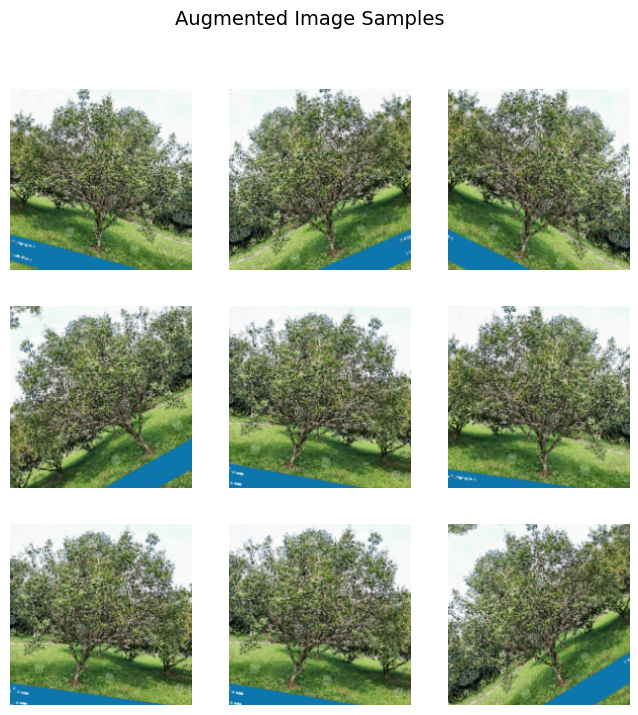

Saved: augmented-images.png


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

for images, _ in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle("Augmented Image Samples", fontsize=14)
    plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/augmented-images.png", bbox_inches='tight')
    plt.show()
    print("Saved: augmented-images.png")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 180, 180, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 90, 90, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 90, 90, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 45, 45, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 45, 45, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 30976)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 128)              │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 20)               │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,991,220 (15.23 MB)

 Trainable params: 3,991,220 (15.23 MB)

 Non-trainable params: 0 (0.00 B)

/tmp/ipykernel_1375/3127908125.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


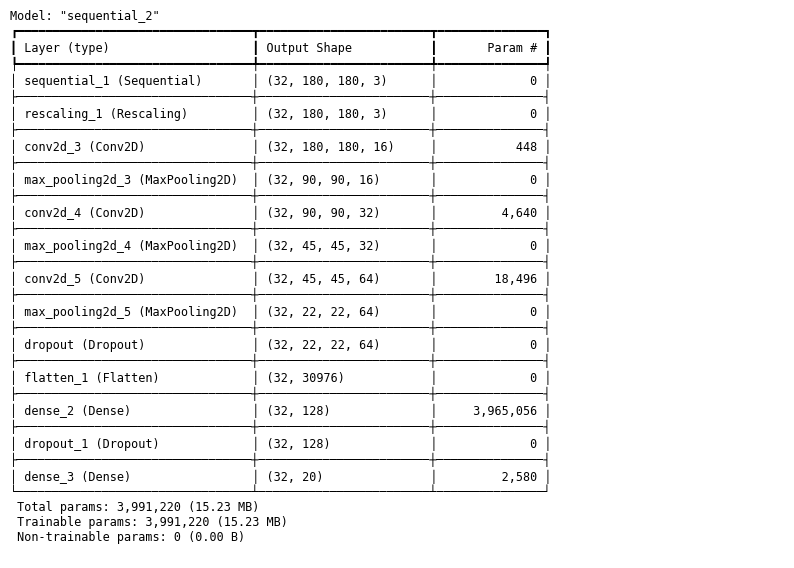

Saved: improved-model-architecture.png


In [ ]:
from tensorflow.keras import layers, models
import io

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names))
])

# Print summary
model.summary()

# Save summary as PNG
summary_lines = []
model.summary(print_fn=lambda x: summary_lines.append(x))
summary_text = "\n".join(summary_lines)

fig, ax = plt.subplots(figsize=(10, len(summary_lines) * 0.28 + 1))
ax.axis("off")
ax.text(0, 1, summary_text, va='top', ha='left', fontsize=8.5,
        fontfamily='monospace', transform=ax.transAxes)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/improved-model-architecture.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: improved-model-architecture.png")

Epoch 1/15
    120/Unknown 163s 1s/step - accuracy: 0.0699 - loss: 3.0593

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


120/120 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.0701 - loss: 3.0582 - val_accuracy: 0.1508 - val_loss: 2.9908
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.1781 - loss: 2.6880 - val_accuracy: 0.2391 - val_loss: 2.5417
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.2420 - loss: 2.5069 - val_accuracy: 0.2674 - val_loss: 2.4326
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.2832 - loss: 2.3444 - val_accuracy: 0.3239 - val_loss: 2.2798
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.3300 - loss: 2.2165 - val_accuracy: 0.4170 - val_loss: 2.0450
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.3631 - loss: 2.0630 - val_accuracy: 0.4523 - val_loss: 1.9036
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4102 - loss: 1.9388 - val_accuracy: 0.4417 - val_loss: 1.9951
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4445 - loss: 1.8378 - val_accuracy: 0.514

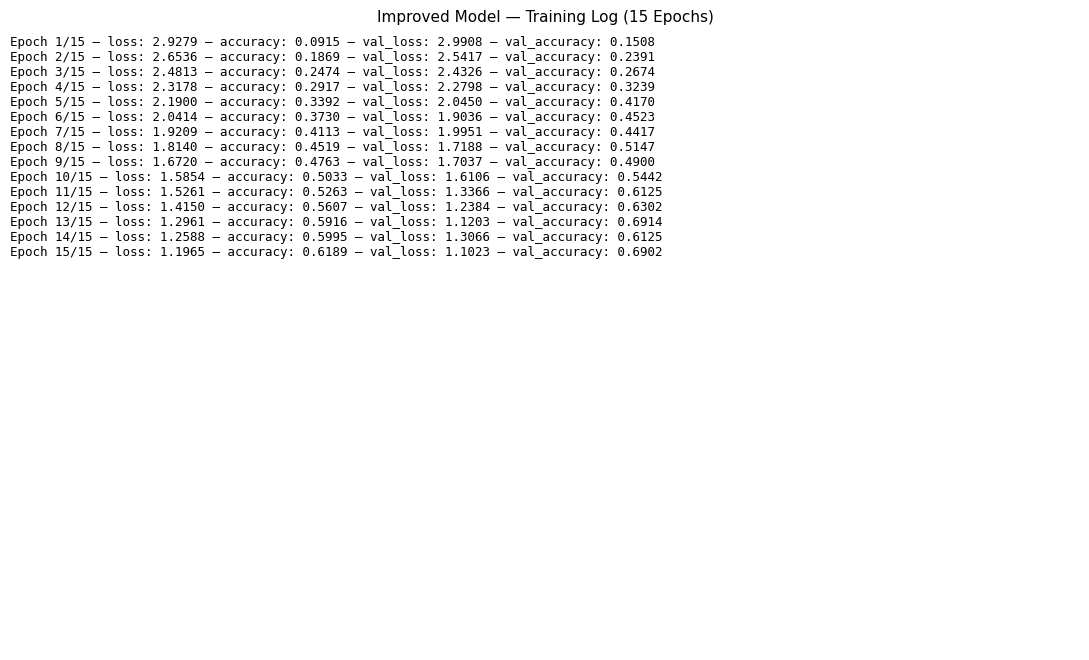

Saved: improved-training-process.png


In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Capture training output as text for screenshot
import sys

class LogCapture(tf.keras.callbacks.Callback):
    def __init__(self):
        self.logs = []
    def on_epoch_end(self, epoch, logs=None):
        line = (f"Epoch {epoch+1}/15 — "
                f"loss: {logs['loss']:.4f} — "
                f"accuracy: {logs['accuracy']:.4f} — "
                f"val_loss: {logs['val_loss']:.4f} — "
                f"val_accuracy: {logs['val_accuracy']:.4f}")
        self.logs.append(line)

log_capture = LogCapture()

epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[log_capture]
)

# Save training log as PNG
fig, ax = plt.subplots(figsize=(11, len(log_capture.logs) * 0.38 + 1))
ax.axis("off")
ax.text(0, 1, "\n".join(log_capture.logs), va='top', ha='left',
        fontsize=9, fontfamily='monospace', transform=ax.transAxes)
plt.title("Improved Model — Training Log (15 Epochs)", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/improved-training-process.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: improved-training-process.png")

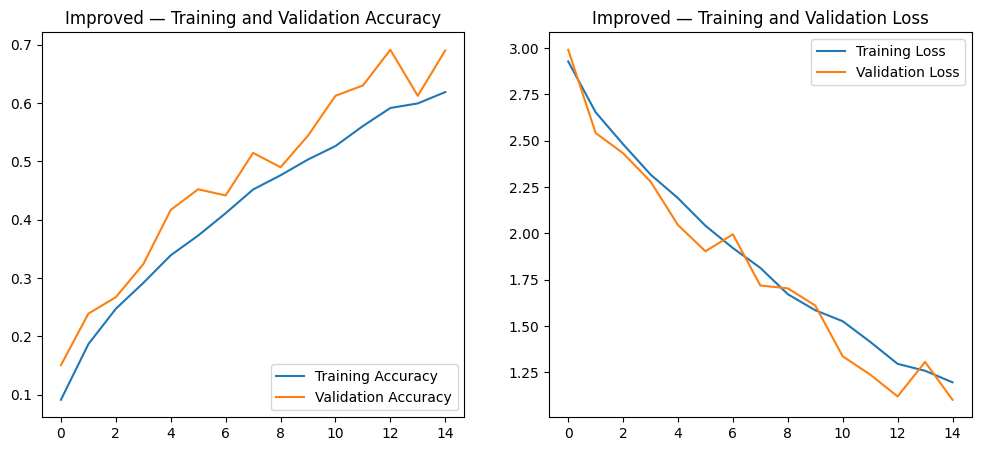

Saved: improved-accuracy-loss-plot.png


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Improved — Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Improved — Training and Validation Loss')

plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/improved-accuracy-loss-plot.png",
            bbox_inches='tight')
plt.show()
print("Saved: improved-accuracy-loss-plot.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted Class: Cedar of Lebanon (Cedrus libani)
Confidence     : 74.25 %


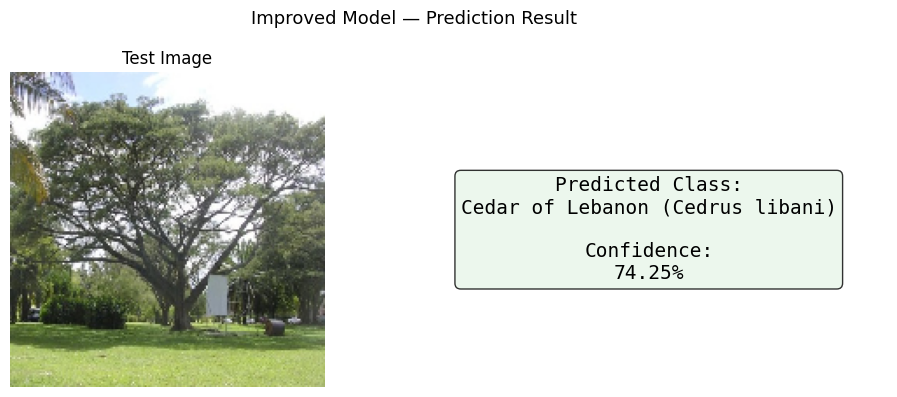

Saved: improved-prediction-test.png


In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/drive/MyDrive/4th yr/ImageDataset/test.jpg"
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

predicted_class = class_names[np.argmax(score)]
confidence = round(100 * np.max(score), 2)

print("Predicted Class:", predicted_class)
print("Confidence     :", confidence, "%")

# Save prediction result as PNG
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: show the image
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title("Test Image", fontsize=12)

# Right: show result text
axes[1].axis("off")
result_text = (f"Predicted Class:\n{predicted_class}\n\n"
               f"Confidence:\n{confidence}%")
axes[1].text(0.5, 0.5, result_text, va='center', ha='center',
             fontsize=14, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8),
             transform=axes[1].transAxes)

plt.suptitle("Improved Model — Prediction Result", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/improved-prediction-test.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: improved-prediction-test.png")

Model saved successfully.
Model loaded successfully.


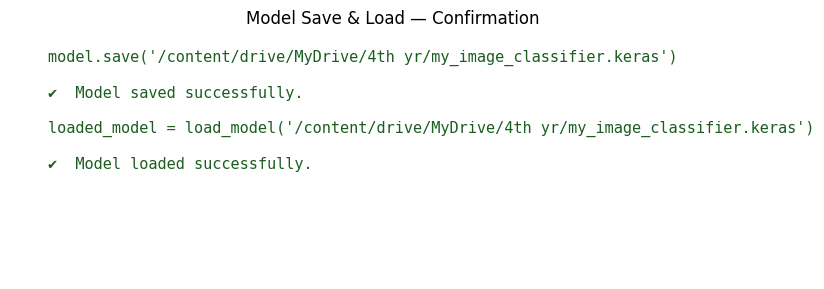

Saved: improved-model-saved.png


In [ ]:
model.save("/content/drive/MyDrive/4th yr/my_image_classifier.keras")
print("Model saved successfully.")

from tensorflow.keras.models import load_model
loaded_model = load_model("/content/drive/MyDrive/4th yr/my_image_classifier.keras")
print("Model loaded successfully.")

# Save confirmation as PNG
save_lines = [
    "model.save('/content/drive/MyDrive/4th yr/my_image_classifier.keras')",
    "",
    "✔  Model saved successfully.",
    "",
    "loaded_model = load_model('/content/drive/MyDrive/4th yr/my_image_classifier.keras')",
    "",
    "✔  Model loaded successfully.",
]

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
ax.text(0.05, 0.95, "\n".join(save_lines), va='top', ha='left',
        fontsize=11, fontfamily='monospace', transform=ax.transAxes,
        color='#1b5e20')
plt.title("Model Save & Load — Confirmation", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/csc-lw3a_screenshots/improved-model-saved.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: improved-model-saved.png")